# Bivariate OLS

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
import matplotlib.font_manager as fm
from matplotlib import ticker

In [7]:
plt.rcParams["font.family"] = "Arial"

Figure 3.1 (only the interesting axis due to lack of data)

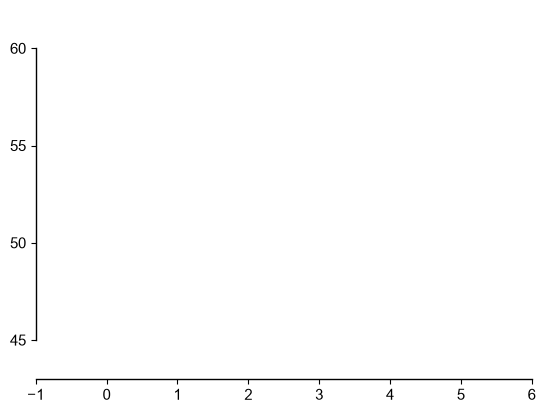

In [16]:
fig, ax = plt.subplots()

ax.set_xlim(-1, 6)
ax.set_ylim(43, 62)

# Ticks
ax.set_xticks(np.arange(-1, 7))
ax.set_yticks([45, 50, 55, 60])

# Remove the extra spines 
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# For the broken spine effect 
ax.spines["left"].set_bounds(45, 60)


ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

plt.show()

### Fig 3.4

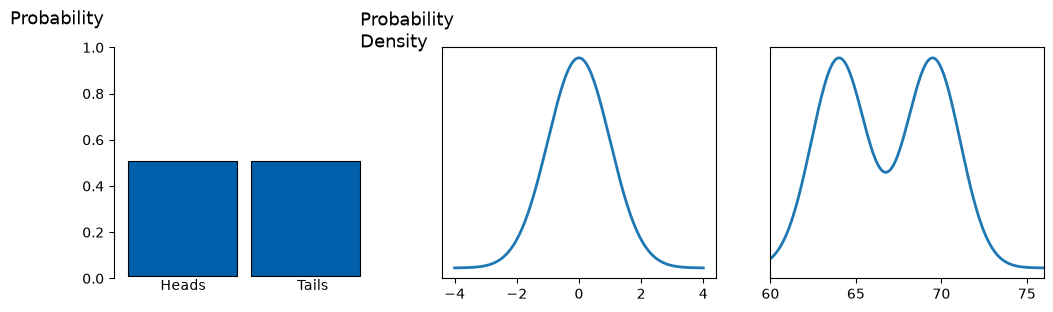

In [ ]:
from matplotlib.patches import Rectangle
from scipy.stats import norm

fig, axes= plt.subplots(1,3, figsize=(12,3))


ax= axes[0]

ax.spines[["bottom", "top", "right"]].set_visible(False)
ax.xaxis.set_major_locator(ticker.NullLocator())
ax.add_patch(Rectangle((0.05,0.01), 0.4, 0.5,
                     edgecolor="black", linewidth=0.8,
                     facecolor= "#0060ac")
)

ax.add_patch(Rectangle((0.5,0.01), 0.4, 0.5,
                     edgecolor="black", linewidth=0.8,
                     facecolor= "#0060ac")
)

ax.text(0.17, -0.05, "Heads")
ax.text(0.67, -0.05, "Tails")
ax.text(-0.38,1.1, "Probability", fontsize=13, transform=ax.transAxes)

ax=axes[1]
ax.yaxis.set_major_locator(ticker.NullLocator())
x = np.linspace(-4, 4, 1000)
y = norm.pdf(x, loc=0, scale=1)
ax.text(-0.3,1, "Probability \nDensity", fontsize=13, transform=ax.transAxes)
ax.plot(x, y, lw=2)

ax= axes[2]
ax.yaxis.set_major_locator(ticker.NullLocator())


#A bimodal distribution is just 2 normal distributions added
x = np.linspace(60, 76, 1000)
y = (
    0.5 * norm.pdf(x, loc=64, scale=1.6) +
    0.5 * norm.pdf(x, loc=69.5, scale=1.6)
)

ax.plot(x, y, lw=2)

ax.set_xlim(60, 76)
ax.set_xticks([60, 65, 70, 75])
ax.set_yticks([])

plt.show()

### Figure 3.6

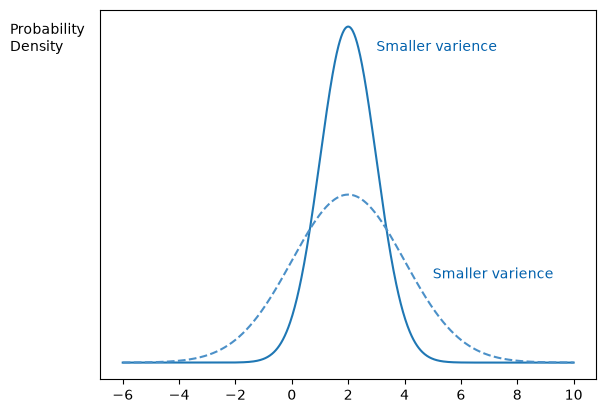

In [153]:
fig, ax= plt.subplots()

x= np.linspace(-6,10,1000)
y= norm.pdf(x, loc=2,scale=1)
z= norm.pdf(x, loc=2,scale=2)

ax.plot(x,y)
ax.plot(x,z, linestyle='--', color= "#4b90c8")

ax.yaxis.set_major_locator(ticker.NullLocator())

ax.text(-10, 0.37, "Probability \nDensity")
ax.text(3, 0.37, "Smaller varience", color="#0060ac" )
ax.text(5, 0.1, "Smaller varience", color="#0060ac" )

plt.show()

Other figures are just the same or lack data

# Computing Corner

I will be using StatsModels library for the econometrics application 

In [161]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

To run the OLS, first we have to clean the donuts data from chapter 2 a bit

In [ ]:
# We will import the donut data we cleaned in the chapter 2

DonutDF= pd.read_csv(r"C:\Users\khosl\OneDrive\Documents\Py notebook\Books\Real Econometrics\donuts.csv")
display(DonutDF.head())

,name,donuts,weight,child,male
0,Homer,14.0,275.0,0.0,0.0
1,Marge,0.0,141.0,0.0,1.0
2,Lisa,0.0,70.0,1.0,1.0
3,Bart,5.0,75.0,1.0,0.0
4,Comic Book Guy,20.0,310.0,0.0,0.0


In [212]:
DonutDF.info()
# donutsx is a string and I remember from chapter 2 that there is a random "5" in "donutsx"

<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    13 non-null     str    
 1   donuts  13 non-null     float64
 2   weight  13 non-null     float64
 3   child   13 non-null     float64
 4   male    13 non-null     float64
dtypes: float64(4), str(1)
memory usage: 652.0 bytes


Python and R both are object oriented programming languages,(though python can allow functional programming), and statsmodels also saves the information about the regression into an that object we can name. And we will name the object, DonutOLS. The syntax of statsmodels.formula (smf) is quite similar to the one in R. We have to call smf and in that the function ols. The formula is straight forward with dependent variable ~ independent variable. We will go deeper into what is python doing here but in general statsmodels.formula is at a higher level than statsmodel (sm) which is not important to get into right now, but yes eventually sm is more hands on and gives you more control but smf does what we need right now.

In [215]:
DonutOLS= smf.ols(

 # With formula we let python know that we want a model with donuts as a linear function of weightx 
 # Meaning weightx= β0 + β1 donutsx + μ 
 # But right now Python does not know what β0 and β1 are        
        formula= "weight ~ donuts",

 # Now the .fit() is what tells python that it should find βs which best fit the data
 # So python is running the minimization of ∑(yi-ŷi)²
        data=DonutDF).fit()


print(DonutOLS.summary())

                            OLS Regression Results                            
Dep. Variable:                 weight   R-squared:                       0.668
Model:                            OLS   Adj. R-squared:                  0.638
Method:                 Least Squares   F-statistic:                     22.16
Date:                Sat, 04 Jul 2026   Prob (F-statistic):           0.000643
Time:                        00:30:26   Log-Likelihood:                -67.080
No. Observations:                  13   AIC:                             138.2
Df Residuals:                      11   BIC:                             139.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    121.6134     16.593      7.329      0.0

If it helps we can also do which makes the process more explicit
* We make a model
* Tell python to fit it
* Get the results

`model=smf.ols("y~x", data=df)`

`results=model.fit()`

`print(results.summery())`

It is weird that the results we are getting are different from what the book gets, but this could be a data change on the author's side.

statsmodel does not show the standard error of regression (̂σ), to get it we have to do, √DonutOLS.scale as .scale gives the Variance of regression or Mean square error (MSE) and it's root will give standard error of regression or as it is called in R Residual Standard Error

In [216]:
print(DonutOLS.scale, "This is the Variance of Regression")
print(np.sqrt(DonutOLS.scale), "This is the Standard error of Error")

2098.9071455265253 This is the Variance of Regression
45.81383137794224 This is the Standard error of Error


Other information that R creates is almost identical to what statsmodel makes and can be accessed in the same way

In [ ]:
display(DonutOLS.fittedvalues)
display(DonutOLS.resid)


0     250.742775
1     121.613413
2     121.613413
3     167.731042
4     306.083931
5     128.531057
6     123.919294
7     269.189827
8     149.283990
9     140.060465
10    128.992234
11    167.731042
12    158.507516
dtype: float64

0     24.257225
1     19.386587
2    -51.613413
3    -92.731042
4      3.916069
5    -48.531057
6     36.080706
7     -6.189827
8     55.716010
9     44.939535
10    41.007766
11   -12.731042
12   -13.507516
dtype: float64

In [ ]:
# Unfortunately statsmodel or python does not have
# A help(lm) type command, the closest we do have is dir
# This gives us all the things we can perform after writing DonutOLS

dir(DonutOLS)

['HC0_se',
 'HC1_se',
 'HC2_se',
 'HC3_se',
 '_HCCM',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abat_diagonal',
 '_cache',
 '_data_attr',
 '_data_in_cache',
 '_get_robustcov_results',
 '_get_wald_nonlinear',
 '_is_nested',
 '_transform_predict_exog',
 '_use_t',
 '_wexog_singular_values',
 'aic',
 'bic',
 'bse',
 'centered_tss',
 'compare_f_test',
 'compare_lm_test',
 'compare_lr_test',
 'condition_number',
 'conf_int',
 'conf_int_el',
 'cov_HC0',
 'cov_HC1',
 'cov_HC2',
 'cov_HC3',
 'cov_kwds',
 'cov_params',
 'cov_type',
 'df_model',
 'df_resid',
 'diagn',
 'eigenvals',
 'el_test',
 'ess',
 'f_pval